In [1]:
# ABOUTME: Interactive notebook teaching image embeddings through hands-on exploration
# ABOUTME: Uses ResNet-18, Oxford Pets dataset, PCA, and jscatter for interactive visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchvision
from torchvision import models, transforms
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from PIL import Image
import jscatter
import base64
from io import BytesIO

%matplotlib widget


def pil_to_data_uri(img, size=128, fmt='JPEG'):
    """Convert a PIL image to a base64 data URI for jscatter tooltip preview."""
    thumb = img.copy()
    thumb.thumbnail((size, size))
    buf = BytesIO()
    thumb.save(buf, format=fmt)
    b64 = base64.b64encode(buf.getvalue()).decode('utf-8')
    mime = 'image/jpeg' if fmt == 'JPEG' else 'image/png'
    return f"data:{mime};base64,{b64}"

# What Are Embeddings? From Pixels to Meaning

**Scenario:** You're building a photo organizer. You have thousands of pet photos — dogs, cats, hamsters, parrots — and you want the app to automatically group similar photos together.

But how does a computer know that two photos of golden retrievers are "similar"? They're just grids of colored pixels. A photo of a golden retriever on a beach looks nothing like one on a couch if you compare pixel by pixel.

The answer: **embeddings**.

An **embedding** is a list of numbers (a vector) that a neural network produces to summarize what it "sees" in an image. The magic is that **similar images get similar vectors** — so comparing images becomes as simple as comparing lists of numbers.

In this notebook, we'll:
1. Feed pet photos through a pretrained neural network
2. Extract the embeddings it produces
3. Visualize them in 2D — and discover that dogs cluster with dogs, cats with cats

## The GPS Analogy

Think of embeddings like GPS coordinates for *meaning*.

Two cafés on the same street have similar GPS coordinates — not because their menus are the same, but because they're *close* in physical space. Similarly, two dog photos have similar embeddings — not because their pixels match, but because the neural network has learned they represent the *same kind of thing*.

| Concept | GPS | Embeddings |
|---------|-----|------------|
| **Space** | Latitude + Longitude (2D) | 512 numbers (512D) |
| **Closeness** | Nearby locations | Similar meanings |
| **Distance** | Meters between points | Cosine similarity between vectors |

The catch: embedding space has **hundreds of dimensions**, not just 2. We can't visualize 512 dimensions directly — but we can compress them to 2D using a technique called **PCA**. More on that soon.

In [2]:
# ============================================================================
# CONFIGURATION
# ============================================================================

N_IMAGES = 40          # Total images to use (half dogs, half cats)
SEED = 42              # Reproducibility
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = "./data"    # Where to cache the Oxford Pets dataset
THUMBNAIL_SIZE = 128   # Pixels for jscatter tooltip thumbnails

print(f"Device: {DEVICE}")
print(f"Will load {N_IMAGES} images ({N_IMAGES // 2} dogs + {N_IMAGES // 2} cats)")

Device: cuda
Will load 40 images (20 dogs + 20 cats)


## Loading Our Data

We'll use the **Oxford-IIIT Pets** dataset — a collection of 7,349 high-quality images of 37 breeds of cats and dogs. Each image comes with a binary label: Cat or Dog.

The first time you run this cell, it will download the dataset (~800MB). After that, it's cached locally.

In [3]:
# ============================================================================
# LOAD DATASET
# ============================================================================

np.random.seed(SEED)
torch.manual_seed(SEED)

# Download Oxford Pets with binary labels (0 = Cat, 1 = Dog)
dataset = torchvision.datasets.OxfordIIITPet(
    root=DATA_DIR, split='trainval',
    target_types='binary-category',
    download=True
)

# Separate indices by class
cat_indices = [i for i, (_, label) in enumerate(dataset) if label == 0]
dog_indices = [i for i, (_, label) in enumerate(dataset) if label == 1]

# Sample equally from each class
n_per_class = N_IMAGES // 2
sampled_cat_idx = np.random.choice(cat_indices, n_per_class, replace=False)
sampled_dog_idx = np.random.choice(dog_indices, n_per_class, replace=False)
sampled_indices = np.concatenate([sampled_cat_idx, sampled_dog_idx])
np.random.shuffle(sampled_indices)

# Load images and labels
images = []
labels = []
label_names = {0: "Cat", 1: "Dog"}

for idx in sampled_indices:
    img, label = dataset[idx]
    images.append(img)
    labels.append(label_names[label])

print(f"Loaded {len(images)} images: {labels.count('Cat')} cats, {labels.count('Dog')} dogs")
print(f"Image sizes vary: {images[0].size}, {images[1].size}, ...")

Loaded 40 images: 20 cats, 20 dogs
Image sizes vary: (448, 336), (500, 375), ...


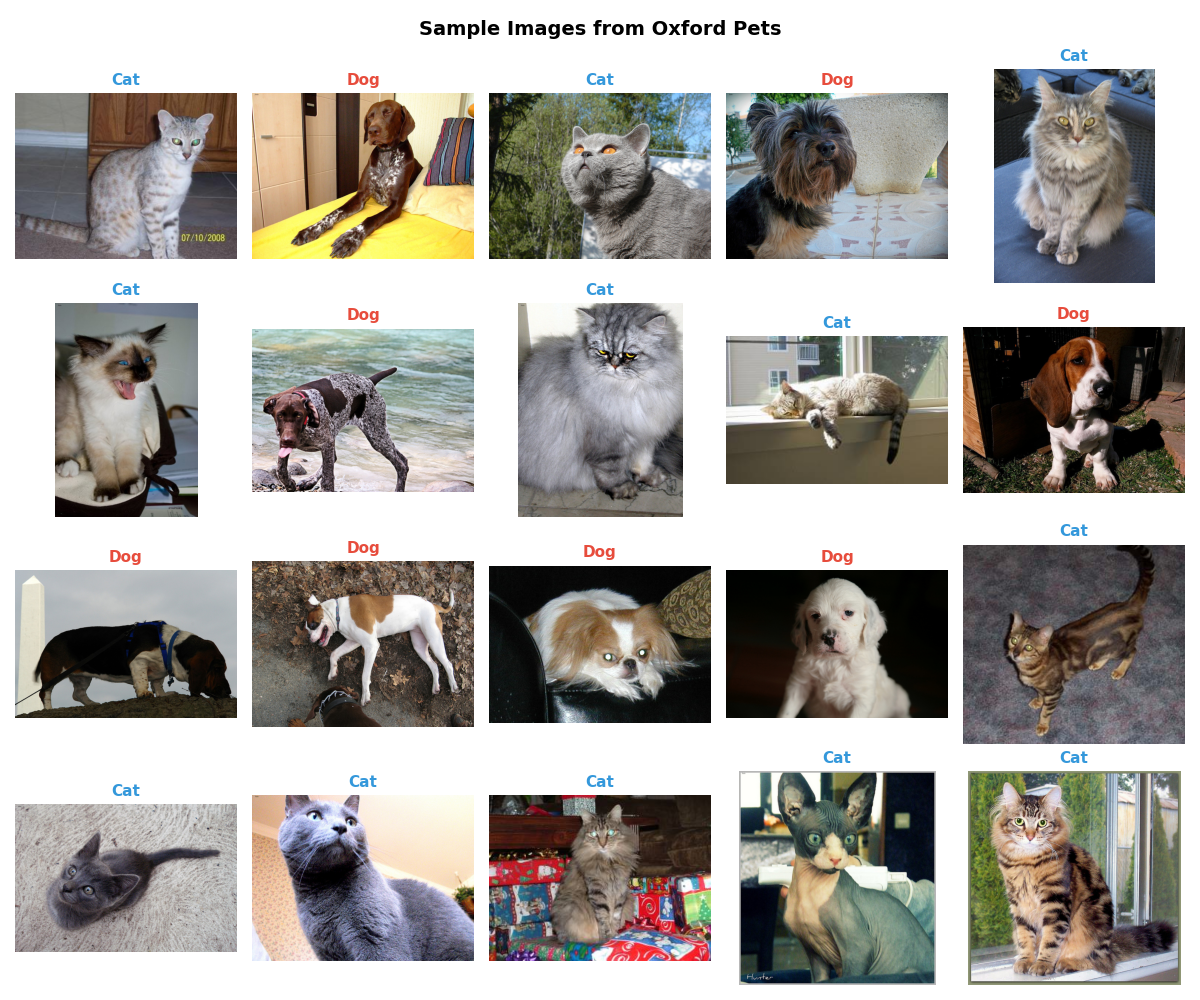

In [4]:
# ============================================================================
# DISPLAY A SAMPLE GRID
# ============================================================================

n_show = min(20, len(images))
n_cols = 5
n_rows = (n_show + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 2.5 * n_rows))
axes = axes.flatten()

for i in range(n_show):
    axes[i].imshow(images[i])
    color = '#e74c3c' if labels[i] == 'Dog' else '#3498db'
    axes[i].set_title(labels[i], fontsize=11, fontweight='bold', color=color)
    axes[i].axis('off')

for i in range(n_show, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Sample Images from Oxford Pets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Converting Images to Numbers

We'll use **ResNet-18**, a neural network pretrained on ImageNet (1.2 million images, 1000 categories). It has already learned to recognize shapes, textures, and objects — we just need to borrow its "vision".

When an image passes through ResNet-18, the final layer produces a vector of **512 numbers**. That's the embedding — a compact summary of what the network sees.

In [5]:
# ============================================================================
# LOAD PRETRAINED RESNET-18
# ============================================================================

# Load model and remove the classification head — we only want embeddings
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
resnet.eval()
resnet = resnet.to(DEVICE)

# The standard ImageNet preprocessing pipeline
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print(f"ResNet-18 loaded on {DEVICE}")
print(f"Output embedding dimension: 512")

ResNet-18 loaded on cuda
Output embedding dimension: 512


In [6]:
# ============================================================================
# EXTRACT EMBEDDINGS
# ============================================================================

# Hook into the avgpool layer to get 512-dim embeddings (before the classifier)
embeddings_list = []

def hook_fn(module, input, output):
    embeddings_list.append(output.squeeze().detach().cpu().numpy())

hook = resnet.avgpool.register_forward_hook(hook_fn)

print("Computing embeddings...")
with torch.no_grad():
    for img in images:
        tensor = preprocess(img).unsqueeze(0).to(DEVICE)
        _ = resnet(tensor)

hook.remove()

embeddings = np.array(embeddings_list)
print(f"Embeddings shape: {embeddings.shape}")
print(f"Each image is now a vector of {embeddings.shape[1]} numbers")

Computing embeddings...
Embeddings shape: (40, 512)
Each image is now a vector of 512 numbers


## What Does an Embedding Look Like?

Each image is now a vector of 512 numbers. Let's peek at the raw values — they don't mean much individually, but their *pattern* encodes what the network sees.

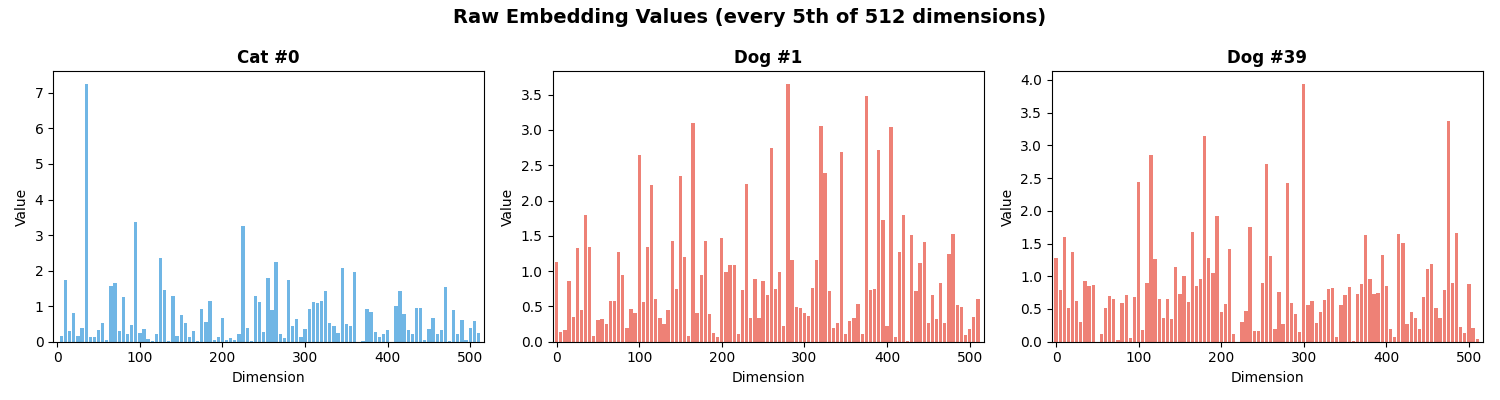

In [7]:
# ============================================================================
# RAW EMBEDDING BAR CHARTS
# ============================================================================

# Pick 3 images to compare: first cat, first dog, second dog
show_indices = [
    labels.index('Cat'),
    labels.index('Dog'),
    len(labels) - 1 - labels[::-1].index('Dog')
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_map = {'Cat': '#3498db', 'Dog': '#e74c3c'}

for ax, idx in zip(axes, show_indices):
    emb = embeddings[idx]
    color = colors_map[labels[idx]]

    # Show every 5th dimension for readability
    step = 5
    x = np.arange(0, 512, step)
    ax.bar(x, emb[::step], width=step * 0.8, color=color, alpha=0.7)
    ax.axhline(y=0, color='gray', linewidth=0.5)
    ax.set_title(f'{labels[idx]} #{idx}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Dimension')
    ax.set_ylabel('Value')
    ax.set_xlim(-5, 517)

fig.suptitle('Raw Embedding Values (every 5th of 512 dimensions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## From 512 Dimensions to 2: PCA

We can't plot 512 dimensions on a screen. **PCA** (Principal Component Analysis) finds the 2 directions in the 512-dimensional space that capture the most variation — like finding the best camera angle to photograph a crowd so you can tell groups apart.

PCA compresses 512 → 2 with minimal information loss. The "explained variance" tells us how much of the original structure we preserved.

In [8]:
# ============================================================================
# PCA DIMENSIONALITY REDUCTION
# ============================================================================

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance preserved: {sum(pca.explained_variance_ratio_) * 100:.1f}%")
print(f"\nProjected shape: {embeddings_2d.shape} (from {embeddings.shape})")

Explained variance ratio: [0.14937612 0.09765068]
Total variance preserved: 24.7%

Projected shape: (40, 2) (from (40, 512))


In [9]:
# ============================================================================
# GENERATE DATA URIs FOR JSCATTER TOOLTIP
# ============================================================================

thumbnail_uris = [pil_to_data_uri(img, size=THUMBNAIL_SIZE) for img in images]

print(f"Generated {len(thumbnail_uris)} thumbnail data URIs")
print(f"Example URI prefix: {thumbnail_uris[0][:50]}...")

Generated 40 thumbnail data URIs
Example URI prefix: data:image/jpeg;base64,/9j/4AAQSkZJRgABAQAAAQABAAD...


## Interactive Embedding Map

Here's the payoff. Each point below is one of our pet photos, projected from 512D to 2D. **Hover over a point** to see the actual image. **Zoom and pan** to explore.

Do dogs cluster with dogs? Do cats cluster with cats? Are there any "confused" images sitting in the wrong group?

In [10]:
# ============================================================================
# JSCATTER INTERACTIVE PLOT
# ============================================================================

# Build the DataFrame that jscatter consumes
df = pd.DataFrame({
    'pca_x': embeddings_2d[:, 0],
    'pca_y': embeddings_2d[:, 1],
    'label': pd.Categorical(labels),
    'thumbnail': thumbnail_uris,
})

scatter = jscatter.Scatter(
    data=df, x='pca_x', y='pca_y',
    height=500,
)
scatter.color(by='label', map={'Dog': '#e74c3c', 'Cat': '#3498db'})
scatter.size(8)
scatter.tooltip(
    enable=True,
    properties=['label'],
    preview='thumbnail',
    preview_type='image',
    preview_image_size='contain',
)
scatter.legend(True)
scatter.show()

## How Similar Are They? The Cosine Similarity Matrix

Cosine similarity measures the angle between two embedding vectors. A value of **1.0** means identical directions (very similar), **0.0** means perpendicular (unrelated), and **-1.0** means opposite.

The heatmap below shows the similarity between every pair of images. Notice the **block diagonal structure** — images of the same class tend to be more similar to each other.

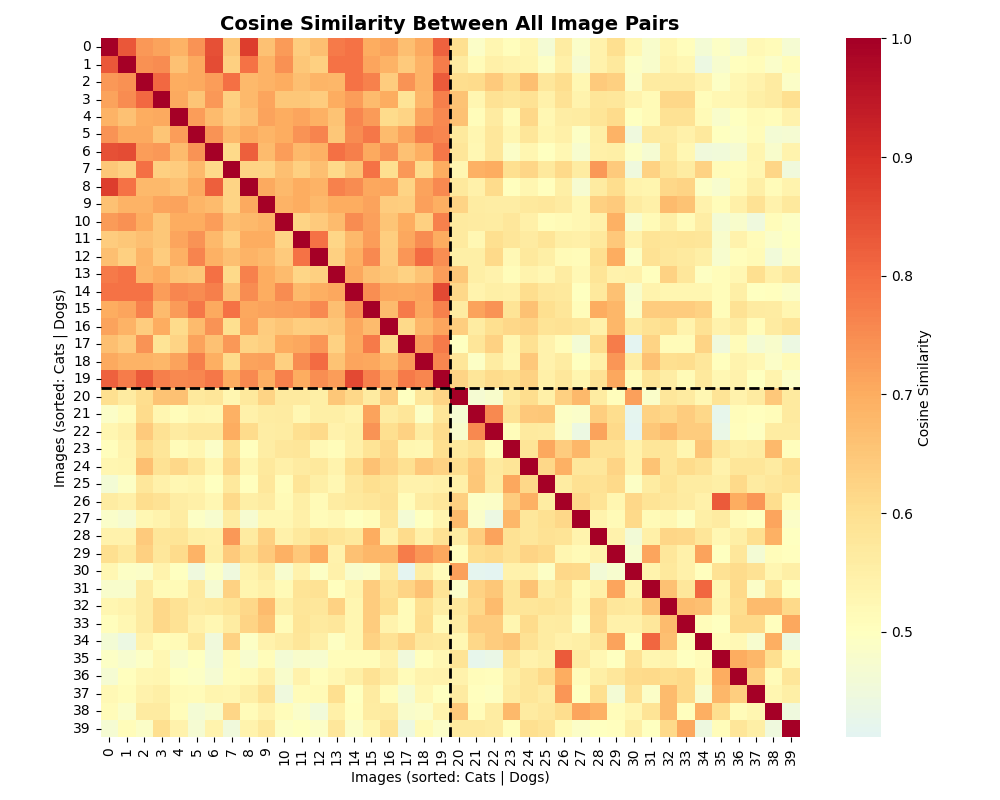


Average similarity:
  Cat vs Cat:  0.707
  Dog vs Dog:  0.577
  Cat vs Dog:  0.554

Same-class images are more similar than cross-class images!


In [11]:
# ============================================================================
# COSINE SIMILARITY HEATMAP
# ============================================================================

# Sort by label so the block structure is visible
sort_idx = np.argsort(labels)
sorted_labels = [labels[i] for i in sort_idx]
sorted_embeddings = embeddings[sort_idx]

sim_matrix = cosine_similarity(sorted_embeddings)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    sim_matrix,
    cmap='RdYlBu_r',
    center=0.5,
    square=True,
    cbar_kws={'label': 'Cosine Similarity'},
    ax=ax,
)

# Add class boundary line
n_cats_sorted = sorted_labels.count('Cat')
ax.axhline(y=n_cats_sorted, color='black', linewidth=2, linestyle='--')
ax.axvline(x=n_cats_sorted, color='black', linewidth=2, linestyle='--')

ax.set_title('Cosine Similarity Between All Image Pairs', fontsize=14, fontweight='bold')
ax.set_xlabel(f'Images (sorted: Cats | Dogs)')
ax.set_ylabel(f'Images (sorted: Cats | Dogs)')

plt.tight_layout()
plt.show()

# Summary statistics
within_cat = sim_matrix[:n_cats_sorted, :n_cats_sorted]
within_dog = sim_matrix[n_cats_sorted:, n_cats_sorted:]
between = sim_matrix[:n_cats_sorted, n_cats_sorted:]

# Exclude diagonal for within-class stats
cat_mask = ~np.eye(n_cats_sorted, dtype=bool)
dog_mask = ~np.eye(len(sorted_labels) - n_cats_sorted, dtype=bool)

print(f"\nAverage similarity:")
print(f"  Cat vs Cat:  {within_cat[cat_mask].mean():.3f}")
print(f"  Dog vs Dog:  {within_dog[dog_mask].mean():.3f}")
print(f"  Cat vs Dog:  {between.mean():.3f}")
print(f"\nSame-class images are more similar than cross-class images!")

## Summary

- **Embeddings** are numerical vectors that encode what a neural network "sees" in an image
- **Similar images** get **similar embeddings** — they end up close in embedding space
- We used **ResNet-18** (pretrained) to extract 512-dimensional embeddings from pet photos
- **PCA** compressed 512 dimensions to 2 so we could visualize the structure
- **Cosine similarity** measures how similar two embeddings are (1.0 = identical, 0.0 = unrelated)

The network learned to separate dogs from cats — but *how*? What does it actually see at each stage of processing? That's what we'll explore in the next notebook: **How Representations Evolve**.